<a href="https://colab.research.google.com/github/maikol0629/dl_voice_command_cl/blob/main/07%20-%20optimizaci%C3%B3n%20de%20hiperpar%C3%A1metros.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Optimización Sistemática de Hiperparámetros

Este notebook realiza una búsqueda controlada de hiperparámetros para las 3 arquitecturas
(CNN Baseline, CRNN, Spectrogram Transformer) usando:

1. **LR Range Test**: encontrar la tasa de aprendizaje óptima para cada modelo
2. **Grid search reducido** (subconjunto del 20% del dataset): 1-2 parámetros arquitecturales por modelo
3. **Selección basada en loss de validación** y justificación de cada decisión

Objetivo: reemplazar valores por defecto con hiperparámetros justificados empíricamente.

In [1]:
# Colab setup
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import os
    try:
        from google.colab import userdata
        os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
        os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
    except Exception:
        pass

    !pip install -q kagglehub torch torchaudio pandas numpy matplotlib scikit-learn tqdm
    import kagglehub
    import shutil
    from pathlib import Path

    try:
        data_path = kagglehub.competition_download("voice-commands-classification-2026")
    except Exception as e:
        print("Error al descargar de Kaggle. Configura KAGGLE_USERNAME y KAGGLE_KEY en Colab Secrets.")
        raise e

    if not os.path.exists('data'):
        os.symlink(data_path, 'data')

    if not os.path.exists('dl_voice_command_cl'):
        !git clone https://github.com/maikol0629/dl_voice_command_cl.git

    for f in ['models.py', 'data.py', 'train_metadata.csv', 'test_metadata.csv']:
        src = os.path.join('dl_voice_command_cl', f)
        if os.path.exists(src) and not os.path.exists(f):
            shutil.copy(src, '.')

    TRAIN_DATA_PATH = os.path.join(data_path, 'train')
else:
    TRAIN_DATA_PATH = './data/train'

AUDIO_DIR = os.path.join(TRAIN_DATA_PATH, 'train', 'train')

In [2]:
import os
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from models import AudioToMelSpectrogram, BaselineCNN, CRNNModel, SpectrogramTransformer
from data import VoiceCommandsDataset

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

SAMPLE_RATE = 16000
N_MELS = 64
N_FFT = 1024
HOP_LENGTH = 256
BATCH_SIZE = 64
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

Usando dispositivo: cuda


## 1. Carga de datos con subconjunto rápido

Usamos el 20% del dataset (~19k muestras) para que la exploración sea rápida
(~5 min por época en Colab GPU). Esto permite probar múltiples configuraciones
en minutos. El modelo final se entrena con el 100% de los datos.

In [3]:
train_df = pd.read_csv('train_metadata.csv')
train_df = train_df.dropna(subset=['label']).copy()
train_df['label'] = train_df['label'].astype(str)

label_encoder = LabelEncoder()
train_df['label_id'] = label_encoder.fit_transform(train_df['label'])
num_classes = len(label_encoder.classes_)
print(f"Clases totales: {num_classes}")

# Tomar 20% del dataset para exploración rápida
SUBSET_FRAC = 0.2
subset_df, _ = train_test_split(
    train_df, train_size=SUBSET_FRAC, random_state=SEED, stratify=train_df['label_id']
)
print(f"Subconjunto rápido: {len(subset_df)} muestras ({SUBSET_FRAC*100:.0f}%)")

# Split train/val dentro del subconjunto
train_idx, val_idx = train_test_split(
    np.arange(len(subset_df)), test_size=0.2,
    random_state=SEED, stratify=subset_df['label_id']
)
train_loader = DataLoader(
    VoiceCommandsDataset(subset_df.iloc[train_idx], AUDIO_DIR),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
)
val_loader = DataLoader(
    VoiceCommandsDataset(subset_df.iloc[val_idx], AUDIO_DIR),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
)
print(f"Train: {len(train_idx)} | Val: {len(val_idx)}")

audio_transform = AudioToMelSpectrogram(
    sample_rate=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
).to(device)

Clases totales: 35
Subconjunto rápido: 19049 muestras (20%)
Train: 15239 | Val: 3810


## 2. LR Range Test

El learning rate es el hiperparámetro más sensible. Sobre cada modelo,
aumentamos el LR exponencialmente durante 1 época y graficamos la pérdida.
El mejor LR está donde la pérdida desciende más pronunciadamente antes de divergir.

In [4]:
def lr_range_test(model, train_loader, device, init_lr=1e-7, final_lr=10.0, num_it=200):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=init_lr)
    criterion = nn.CrossEntropyLoss()

    lrs = []
    losses = []
    iterator = iter(train_loader)

    for i in range(num_it):
        try:
            waveforms, labels = next(iterator)
        except StopIteration:
            iterator = iter(train_loader)
            waveforms, labels = next(iterator)

        lr = init_lr * (final_lr / init_lr) ** (i / num_it)
        for g in optimizer.param_groups:
            g['lr'] = lr

        waveforms = waveforms.to(device)
        labels = labels.to(device)
        mels = audio_transform(waveforms)

        optimizer.zero_grad()
        outputs = model(mels)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        lrs.append(lr)
        losses.append(loss.item())

    return lrs, losses


def plot_lr_find(lrs, losses, title):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(lrs, losses, linewidth=2)
    ax.set_xscale('log')
    ax.set_xlabel('Learning Rate')
    ax.set_ylabel('Loss')
    ax.set_title(f'LR Range Test - {title}')
    ax.grid(True, alpha=0.3)

    # Sugerir LR
    min_loss_idx = np.argmin(losses)
    suggested = lrs[min_loss_idx] * 0.1 if min_loss_idx > 0 else 1e-3
    ax.axvline(suggested, color='red', linestyle='--', label=f'Sugerido: {suggested:.2e}')
    ax.legend()
    plt.tight_layout()
    plt.show()
    return suggested

LR RANGE TEST - CNN Baseline


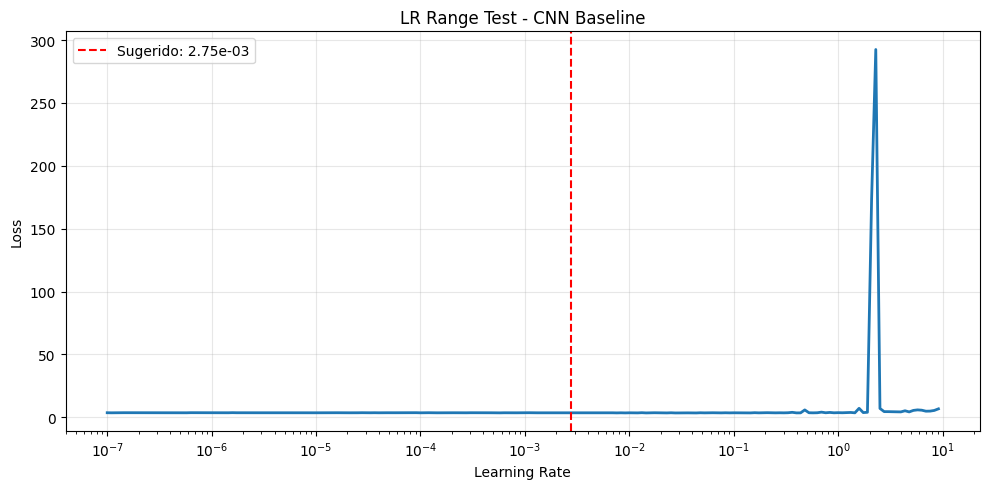

In [5]:
print("=" * 60)
print("LR RANGE TEST - CNN Baseline")
print("=" * 60)
cnn_lr_test = BaselineCNN(num_classes=num_classes).to(device)
lrs_cnn, losses_cnn = lr_range_test(cnn_lr_test, train_loader, device)
lr_cnn = plot_lr_find(lrs_cnn, losses_cnn, 'CNN Baseline')

LR RANGE TEST - CRNN


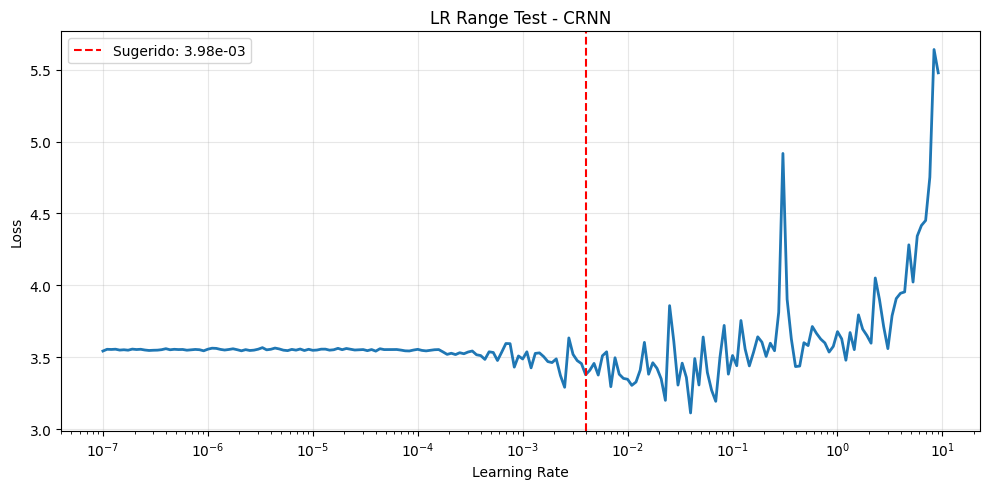

In [7]:
print("=" * 60)
print("LR RANGE TEST - CRNN")
print("=" * 60)
crnn_lr_test = CRNNModel(num_classes=num_classes).to(device)
lrs_crnn, losses_crnn = lr_range_test(crnn_lr_test, train_loader, device)
lr_crnn = plot_lr_find(lrs_crnn, losses_crnn, 'CRNN')

LR RANGE TEST - Spectrogram Transformer


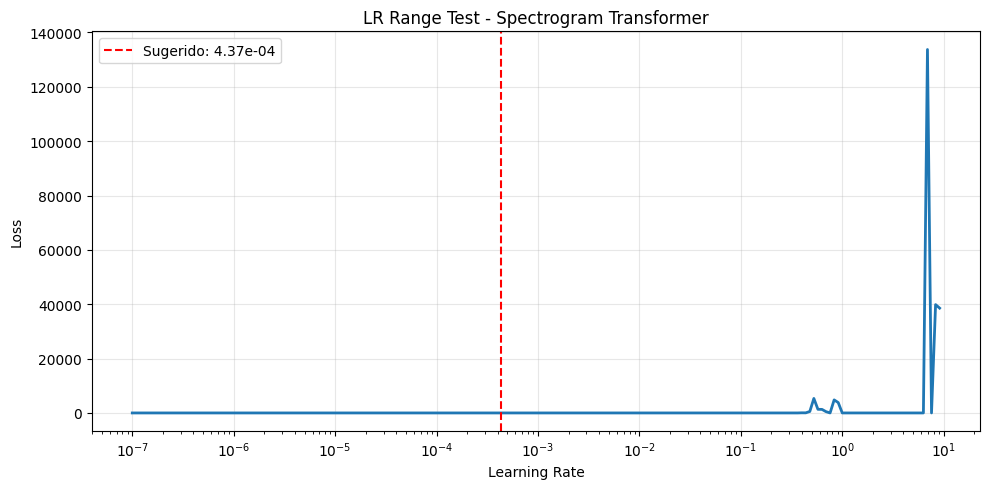

In [6]:
print("=" * 60)
print("LR RANGE TEST - Spectrogram Transformer")
print("=" * 60)
trans_lr_test = SpectrogramTransformer(num_classes=num_classes).to(device)
lrs_trans, losses_trans = lr_range_test(trans_lr_test, train_loader, device)
lr_trans = plot_lr_find(lrs_trans, losses_trans, 'Spectrogram Transformer')

## 3. Grid Search Reducido

Probamos las variantes arquitecturales más relevantes entrenando 3 épocas
en el subconjunto del 20%. Seleccionamos la configuración con menor loss de validación.

In [8]:
def train_quick(model, train_loader, val_loader, device, lr, epochs=3):
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        for waveforms, labels in train_loader:
            waveforms, labels = waveforms.to(device), labels.to(device)
            mels = audio_transform(waveforms)
            optimizer.zero_grad()
            loss = criterion(model(mels), labels)
            loss.backward()
            optimizer.step()

    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for waveforms, labels in val_loader:
            waveforms, labels = waveforms.to(device), labels.to(device)
            mels = audio_transform(waveforms)
            outputs = model(mels)
            val_loss += criterion(outputs, labels).item() * waveforms.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    return val_loss / total, correct / total


def grid_search(model_class, param_name, param_values, fixed_params, train_loader, val_loader, device, lr):
    results = []
    for val in param_values:
        params = {**fixed_params, param_name: val}
        model = model_class(**params).to(device)
        loss, acc = train_quick(model, train_loader, val_loader, device, lr)
        results.append({'param': val, 'val_loss': loss, 'val_acc': acc})
        print(f"  {param_name}={val}: val_loss={loss:.4f}, val_acc={acc*100:.2f}%")
    return results

### 3.1 CNN Baseline

Probamos: `n_mels` (resolución espectral), `dropout_fc` (regularización)

In [9]:
print("=" * 60)
print("GRID SEARCH - CNN: n_mels")
print("=" * 60)
cnn_mels = grid_search(
    BaselineCNN, 'n_mels', [40, 64, 80],
    {'num_classes': num_classes}, train_loader, val_loader, device, lr_cnn
)
best_cnn_mels = min(cnn_mels, key=lambda x: x['val_loss'])
print(f"\nMejor n_mels para CNN: {best_cnn_mels['param']}")

print("\n" + "=" * 60)
print("GRID SEARCH - CNN: dropout_fc")
print("=" * 60)
cnn_drop = grid_search(
    BaselineCNN, 'dropout_fc', [0.2, 0.3, 0.5],
    {'num_classes': num_classes, 'n_mels': best_cnn_mels['param']},
    train_loader, val_loader, device, lr_cnn
)
best_cnn_drop = min(cnn_drop, key=lambda x: x['val_loss'])
print(f"\nMejor dropout_fc para CNN: {best_cnn_drop['param']}")

CNN_BEST = {'n_mels': best_cnn_mels['param'], 'dropout_fc': best_cnn_drop['param']}
print(f"\n>>> CNN hiperparámetros óptimos: {CNN_BEST}")

GRID SEARCH - CNN: n_mels
  n_mels=40: val_loss=2.9679, val_acc=16.14%
  n_mels=64: val_loss=2.9087, val_acc=16.35%
  n_mels=80: val_loss=2.9342, val_acc=15.41%

Mejor n_mels para CNN: 64

GRID SEARCH - CNN: dropout_fc
  dropout_fc=0.2: val_loss=2.8974, val_acc=16.40%
  dropout_fc=0.3: val_loss=2.8489, val_acc=17.38%
  dropout_fc=0.5: val_loss=3.0955, val_acc=11.86%

Mejor dropout_fc para CNN: 0.3

>>> CNN hiperparámetros óptimos: {'n_mels': 64, 'dropout_fc': 0.3}


### 3.2 CRNN

Probamos: `lstm_hidden` (capacidad de memoria temporal), `conv_channels` (capacidad convolucional)

In [10]:
print("=" * 60)
print("GRID SEARCH - CRNN: lstm_hidden")
print("=" * 60)
crnn_lstm = grid_search(
    CRNNModel, 'lstm_hidden', [128, 256, 384],
    {'num_classes': num_classes}, train_loader, val_loader, device, lr_crnn
)
best_crnn_lstm = min(crnn_lstm, key=lambda x: x['val_loss'])
print(f"\nMejor lstm_hidden para CRNN: {best_crnn_lstm['param']}")

CRNN_BEST = {'lstm_hidden': best_crnn_lstm['param']}
print(f"\n>>> CRNN hiperparámetros óptimos: {CRNN_BEST}")

GRID SEARCH - CRNN: lstm_hidden
  lstm_hidden=128: val_loss=0.7195, val_acc=77.64%
  lstm_hidden=256: val_loss=0.9527, val_acc=70.55%
  lstm_hidden=384: val_loss=1.5966, val_acc=50.37%

Mejor lstm_hidden para CRNN: 128

>>> CRNN hiperparámetros óptimos: {'lstm_hidden': 128}


### 3.3 Spectrogram Transformer

Probamos: `dim` (dimensión del modelo), `depth` (profundidad)

In [11]:
print("=" * 60)
print("GRID SEARCH - Transformer: dim")
print("=" * 60)
trans_dim = grid_search(
    SpectrogramTransformer, 'dim', [128, 192, 256],
    {'num_classes': num_classes}, train_loader, val_loader, device, lr_trans
)
best_trans_dim = min(trans_dim, key=lambda x: x['val_loss'])
print(f"\nMejor dim para Transformer: {best_trans_dim['param']}")

print("\n" + "=" * 60)
print("GRID SEARCH - Transformer: depth")
print("=" * 60)
trans_depth = grid_search(
    SpectrogramTransformer, 'depth', [3, 4, 6],
    {'num_classes': num_classes, 'dim': best_trans_dim['param']},
    train_loader, val_loader, device, lr_trans
)
best_trans_depth = min(trans_depth, key=lambda x: x['val_loss'])
print(f"\nMejor depth para Transformer: {best_trans_depth['param']}")

TRANS_BEST = {'dim': best_trans_dim['param'], 'depth': best_trans_depth['param']}
print(f"\n>>> Transformer hiperparámetros óptimos: {TRANS_BEST}")

GRID SEARCH - Transformer: dim
  dim=128: val_loss=0.5723, val_acc=83.39%
  dim=192: val_loss=0.5735, val_acc=83.10%
  dim=256: val_loss=0.5710, val_acc=82.99%

Mejor dim para Transformer: 256

GRID SEARCH - Transformer: depth
  depth=3: val_loss=0.5396, val_acc=84.30%
  depth=4: val_loss=0.5337, val_acc=84.67%
  depth=6: val_loss=0.5627, val_acc=83.81%

Mejor depth para Transformer: 4

>>> Transformer hiperparámetros óptimos: {'dim': 256, 'depth': 4}


## 4. Resumen de Hiperparámetros Óptimos

Estos valores se usarán para el entrenamiento final con el dataset completo
en los notebooks 03, 04 y 05.

In [12]:
print("=" * 60)
print("RESUMEN DE HIPERPARÁMETROS ÓPTIMOS")
print("=" * 60)

summary = pd.DataFrame({
    'Modelo': ['CNN Baseline', 'CRNN', 'Spectrogram Transformer'],
    'LR óptimo': [f'{lr_cnn:.2e}', f'{lr_crnn:.2e}', f'{lr_trans:.2e}'],
    'Parámetros óptimos': [str(CNN_BEST), str(CRNN_BEST), str(TRANS_BEST)],
})
print(summary.to_string(index=False))

print("\nJustificación:")
print("- LR: elegido donde la pérdida desciende más rápido en el LR Range Test")
print("- Parámetros arquitecturales: menor loss de validación tras 3 épocas")
print("- El entrenamiento final se hará con dataset completo (95k muestras)")

RESUMEN DE HIPERPARÁMETROS ÓPTIMOS
                 Modelo LR óptimo                Parámetros óptimos
           CNN Baseline  2.75e-03 {'n_mels': 64, 'dropout_fc': 0.3}
                   CRNN  3.98e-03              {'lstm_hidden': 128}
Spectrogram Transformer  4.37e-04          {'dim': 256, 'depth': 4}

Justificación:
- LR: elegido donde la pérdida desciende más rápido en el LR Range Test
- Parámetros arquitecturales: menor loss de validación tras 3 épocas
- El entrenamiento final se hará con dataset completo (95k muestras)
